**Part 1: Understanding Product Categories**
**Business Question:**
What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

**1. Frequency Tables:**

- Generate a frequency table for the product category.
- Which are the top 5 most listed product categories?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

df = pd.read_csv('amz_uk_price_prediction_dataset.csv')

In [2]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
df['category'].value_counts(ascending=False)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

A: The top 5 most listed product categories are: Sports & Outdoor, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body and Birthday Gifts


**2. Visualizations:**

- Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
- For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

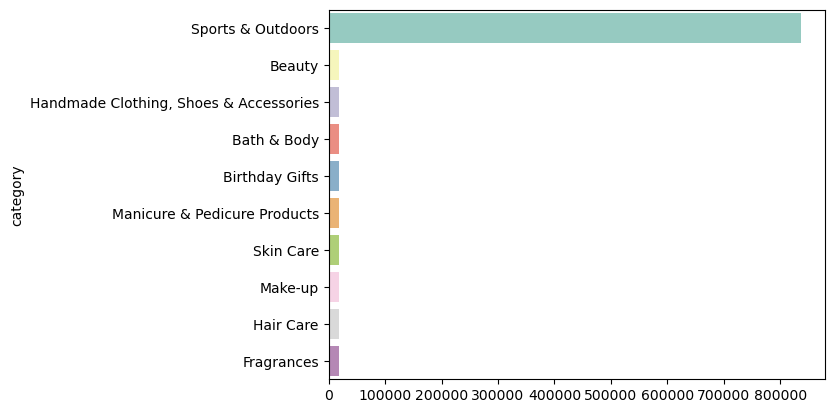

In [7]:
frequency_table = df['category'].value_counts().head(10)

ax=sns.barplot(y=frequency_table.index, x=frequency_table.values, palette="Set3", hue=frequency_table.index, legend=False )

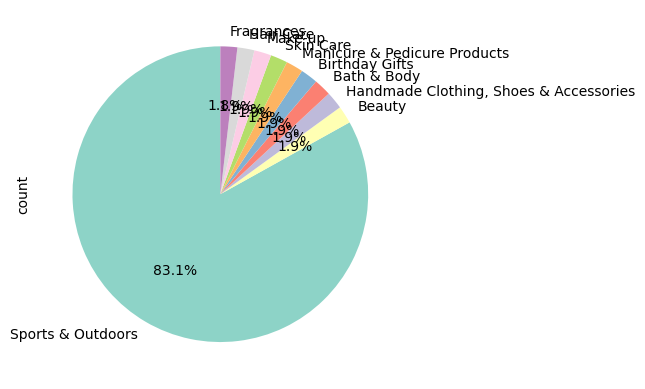

In [9]:
df['category'].value_counts().head(10).plot.pie(autopct='%.1f%%', startangle=90, colors=sns.color_palette("Set3"));
plt.show()

A: Sports & Outdoors dominate the listings.

**Part 2: Delving into Product Pricing**

**Business Question:** How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

**1. Measures of Centrality:**

- Calculate the mean, median, and mode for the price of products.
- What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [12]:
mean = df['price'].mean()
median = df['price'].median()
mode = df['price'].mode()[0]

mean, median, mode

(np.float64(89.24380943923661), 19.09, np.float64(9.99))

A: The average price point is 89.24, which is much higher than the most common price point of 9.99.

**Measures of Dispersion:**

- Determine the variance, standard deviation, range, and interquartile range for product price.
- How varied are the product prices? Are there any indicators of a significant spread in prices?


In [22]:
variance = df['price'].var()
std_dev = df['price'].std()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("Interquartile Range:", IQR)

Variance: 119445.48532256528
Standard Deviation: 345.60886175352226
Interquartile Range: 36.0


A: The large variance (119,445.49) and standard deviation (345.61) indicate that product prices vary significantly. The interquartile range (36) shows that the middle 50% of products are priced within a relatively smaller range compared to the overall spread, suggesting that a few very expensive products increase the overall variability.

**3. Visualizations:**

- Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
- Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

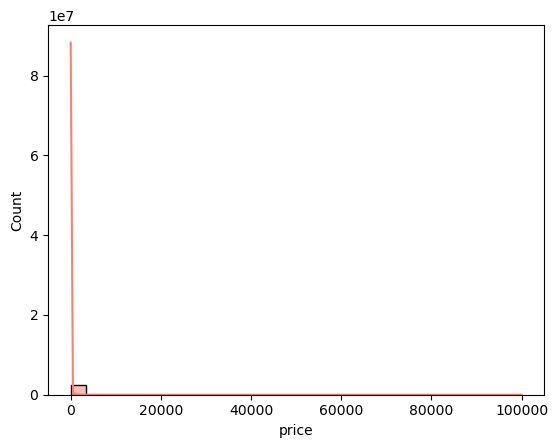

In [15]:
fig, axes = plt.subplots()
sns.histplot(df['price'], kde=True, bins=30, color="salmon", ax=axes);
plt.show()

A: Yes, it is hard to read because the prices are widely spread, and there are not many products with the same price.

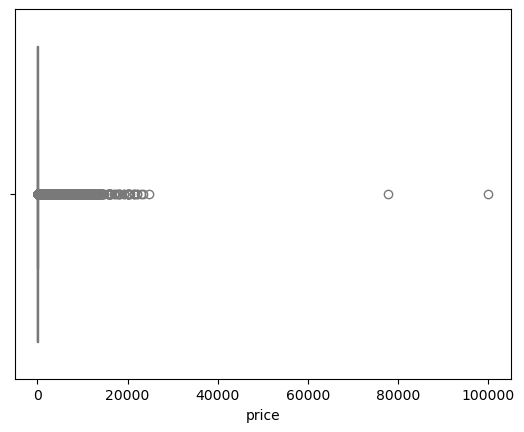

In [18]:
sns.boxplot(x = df['price'], color="lightblue");

A: The box plot reveals several extreme outliers, representing products that are priced significantly higher than the majority of items. Most products fall within a much lower price range, while a few very expensive items extend the distribution.

**Part 3: Unpacking Product Ratings**

**Business Question:** How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

**1. Measures of Centrality:**

- Calculate the mean, median, and mode for the rating of products.
- How do customers generally rate products? Is there a common trend?

In [20]:
mean = df['stars'].mean()
median = df['stars'].median()
mode = df['stars'].mode()[0]

mean, median, mode

(np.float64(2.152836472966066), 0.0, np.float64(0.0))

A: Most customers do not rate the products, as the median and mode are 0.

**2. Measures of Dispersion:**

- Determine the variance, standard deviation, and interquartile range for product rating.
- Are the ratings consistent, or is there a wide variation in customer feedback?

In [21]:
variance = df['stars'].var()
std_dev = df['stars'].std()

Q1 = df['stars'].quantile(0.25)
Q3 = df['stars'].quantile(0.75)
IQR = Q3 - Q1

print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("Interquartile Range:", IQR)

Variance: 4.81743402976196
Standard Deviation: 2.1948653785054697
Interquartile Range: 4.4


A: The variance (4.82) and standard deviation (2.19) show that product ratings vary moderately from the average rating. The interquartile range (4.4) indicates that the middle 50% of ratings lie within a 4.4-point range, suggesting a relatively wide spread in how customers rate products.

**3. Shape of the Distribution:**

- Calculate the skewness and kurtosis for the rating column.
- Are the ratings normally distributed, or do they lean towards higher or lower values?


In [23]:
skewness = df['stars'].skew()
kurtosis = df['stars'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 0.08120735761080881
Kurtosis: -1.9260061280432994


A: The skewness value (0.08) indicates that the rating distribution is approximately symmetric and does not strongly lean toward higher or lower values. The kurtosis value (-1.93) suggests a flatter distribution than normal, meaning there are fewer extreme values.

**4. Visualizations:**

- Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

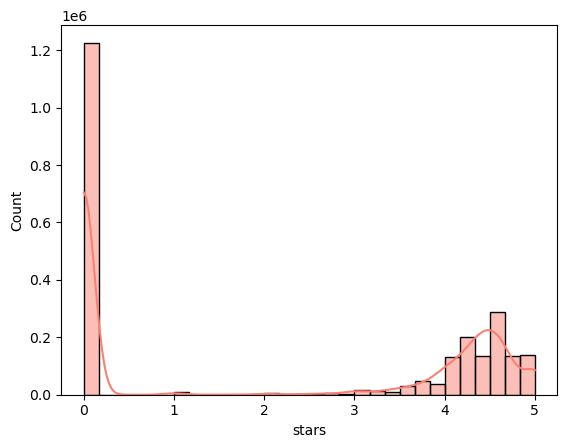

In [24]:
fig, axes = plt.subplots()
sns.histplot(df['stars'], kde=True, bins=30, color="salmon", ax=axes);
plt.show()

A: The histogram shows that the ratings are not normally distributed. There is a very large concentration at 0, indicating that many products have no ratings. Among the products that are rated, most ratings fall between 4 and 5 stars, showing that rated products generally receive high scores.